In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#alpha = N/k

N_0 = 1539351
F = 8.922473368689328

In [78]:
def a_n_function(alpha): # a_n-1 = epsilon
    n = 0
    S = 1
    alphas = [alpha]
    probs = []
    
    for i in range(100):
        p = 1./(1+alpha)
        probs.append(p) 
        q = 1-p
        s = 1+p
        S = S*s
        f = p*q/s
        n = n*s + f
        alpha = alpha*s; alphas.append(alpha)
        epsilon = n/S
    
    return epsilon, alphas, probs

In [79]:
def N_function(N_0, p=0.6):
    return N_0*(1+p)**np.arange(100)

# Michaelis Menten

## number of DNA vs rounds

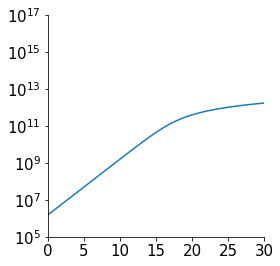

In [80]:
plt.figure(figsize=(4,3.8),facecolor='white')
ax = plt.subplot(111)
for alpha in np.array([1e-5]):
    N_vector = N_0/alpha*np.array(a_n_function(alpha)[1])

    plt.plot(N_vector, label=' k = %.1e'%(N_0/alpha))


plt.xlim(0,30)
plt.ylim(1e5, 1e17)
plt.yscale('log')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('pMM_N_vs_amp_rounds.png', dpi=1200)

## probability vs rounds

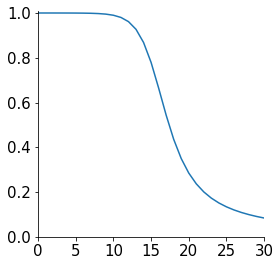

In [81]:
plt.figure(figsize=(4,3.8),facecolor='white')
ax = plt.subplot(111)

for alpha in np.array([1e-5]):
    p_vector = np.array(a_n_function(alpha)[2])

    plt.plot(p_vector, label=' k = %.1e'%(N_0/alpha))

    
plt.xlim(0,30)
plt.ylim(0, 1.01)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('pMM_p_vs_amp_rounds.png',dpi=1200)

## variance vs mean

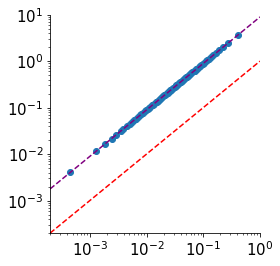

In [82]:
df_bins = pd.read_csv('../simulations_p_MM/df_bins_simulation_Byrne_25amp_rounds.csv',index_col=0)

a,b = 2e-4, 1
c,d = 2e-4,10

plt.figure(figsize=(4,3.8), facecolor='white')
ax = plt.subplot(111)
x = df_bins['mean_count']
y = df_bins['var_count']
plt.plot([a,b],[a,b], linestyle='--', color='red')
plt.plot([a,b], [F*a,F*b],linestyle='--', color='purple')
plt.scatter(x,y, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlim(a,b)
plt.ylim(c,d)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('pMM_var_vs_mean.png', dpi=1200)

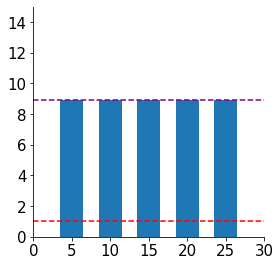

In [83]:
x = np.arange(5,30,5)
y = np.zeros(5)
y_err = np.zeros(5)
i = 0
for amp_rounds in x:
    df_bins = pd.read_csv('../simulations_p_MM/df_bins_simulation_Byrne_%damp_rounds.csv'%amp_rounds)
    F_vec = ((df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count']).mean()
    y[i] = F_vec.mean()
    y_err[i] = F_vec.var()
    i+=1
    
a,b =0,30
c,d =0,15
    
plt.figure(figsize=(4,3.8), facecolor='white')
ax = plt.subplot()
#plt.errorbar(x,y,yerr=y_err, marker='o', linestyle='', color='black')
plt.bar(x,y, width=3)
plt.hlines(1,a,b,linestyle='--', color='red')
plt.hlines(F,a,b,linestyle='--', color='purple')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(a,b)
plt.ylim(c,d)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('pMM_F_vs_amp_rounds.png', dpi=1200)

## different k

## number of DNA vs rounds

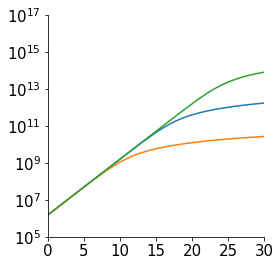

In [84]:
plt.figure(figsize=(4,3.8),facecolor='white')
ax = plt.subplot(111)
for alpha in np.array([1e-5,1e-3,1e-7]):
    N_vector = N_0/alpha*np.array(a_n_function(alpha)[1])

    plt.plot(N_vector, label=' k = %.1e'%(N_0/alpha))


plt.xlim(0,30)
plt.ylim(1e5, 1e17)
plt.yscale('log')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('pMM_N_vs_amp_rounds_diffk.png', dpi=1200)

## probability vs rounds

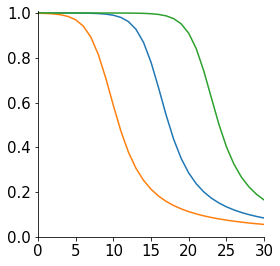

In [85]:
plt.figure(figsize=(4,3.8),facecolor='white')
ax = plt.subplot(111)

for alpha in np.array([1e-5,1e-3,1e-7]):
    p_vector = np.array(a_n_function(alpha)[2])

    plt.plot(p_vector, label=' k = %.1e'%(N_0/alpha))

    
plt.xlim(0,30)
plt.ylim(0, 1.01)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('pMM_p_vs_amp_rounds_diffk.png',dpi=1200)

## Fano factor vs k

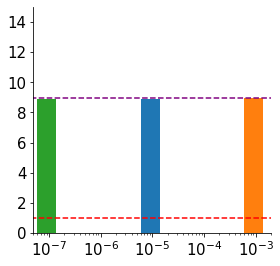

In [90]:
x = np.array([1e-3,1e-7])
y = np.zeros(6)

plt.figure(figsize=(4,3.8), facecolor='white')
ax = plt.subplot(111)

alpha = 1e-5
df_bins = pd.read_csv('../simulations_p_MM/df_bins_simulation_Byrne_25amp_rounds.csv')
F_vec = ((df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count']).mean()
plt.bar(alpha,F_vec.mean(), width=alpha/1.25)

for alpha in x:
    df_bins = pd.read_csv('../simulations_p_MM/df_bins_simulation_Byrne_%.1ek.csv'%(N_0/alpha))
    F_vec = ((df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count']).mean()
    plt.bar(alpha,F_vec.mean(), width=alpha/1.25)
    
    
plt.hlines(1,1e-8,1e-2,linestyle='--', color='red')
plt.hlines(F,1e-8,1e-2,linestyle='--', color='purple')
plt.xscale('log')
plt.xlim(5e-8,2e-3)
plt.ylim(0, 15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.tight_layout()
plt.savefig('pMM_F_vs_alpha_diffk.png', dpi=1200)